<a href="https://colab.research.google.com/github/LCaravaggio/Cosas_Sueltas/blob/main/VIIRS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import os
from google.colab import userdata

import os
from google.colab import userdata

username = "lcaravaggio"
password = userdata.get("NASA")

# Crear .netrc correctamente
netrc_content = f"""machine urs.earthdata.nasa.gov
login {username}
password {password}
"""

with open("/root/.netrc", "w") as f:
    f.write(netrc_content)

os.chmod("/root/.netrc", 0o600)

# Cookie file
!touch ~/.urs_cookies

# Descarga
!wget \
  --load-cookies ~/.urs_cookies \
  --save-cookies ~/.urs_cookies \
  --keep-session-cookies \
  --auth-no-challenge=on \
  --content-disposition \
  "https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VNP46A2/VNP46A2.A2026104.h12v12.002.2026112102916.h5"

--2026-04-22 13:23:21--  https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VNP46A2/VNP46A2.A2026104.h12v12.002.2026112102916.h5
Resolving data.laadsdaac.earthdatacloud.nasa.gov (data.laadsdaac.earthdatacloud.nasa.gov)... 54.192.55.59, 54.192.55.104, 54.192.55.31, ...
Connecting to data.laadsdaac.earthdatacloud.nasa.gov (data.laadsdaac.earthdatacloud.nasa.gov)|54.192.55.59|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://d13j1jds5ybppo.cloudfront.net/s3-8d80a21348b33e9c2ee6e0a8ac41d7b1/prod-lads.s3.us-west-2.amazonaws.com/VNP46A2/VNP46A2.A2026104.h12v12.002.2026112102916.h5?A-userid=lcaravaggio&Expires=1776867802&Signature=EWebhTnTIOIa~GY7vjQ9~4WNofYFyIwvExAcWMsd~Akh6CI-eseOXqIkg8ULTTFUEig6NliVKxr6xn2RfANMRAzxFDC8eJpTV23gDYi8TvSsYeVPd2O42BR8l5uJG7qNlOZudt5QeZRW~4GtECO003FOYJ06dAy-qHFSTSg7Cku9BomFySwBEXBFjqaVz5KG0EcvXvgvH6iMr8pftRABGRaLEM-A-0jzw-7uOrl78wfFuX3fqE7u0GLCuU9ea81KQTuye8aStM-C9ZnVlACgv4ppsgscCzBViz9bvDZctqS~MZ7Fx2t8UO5iDNXCs9YmI

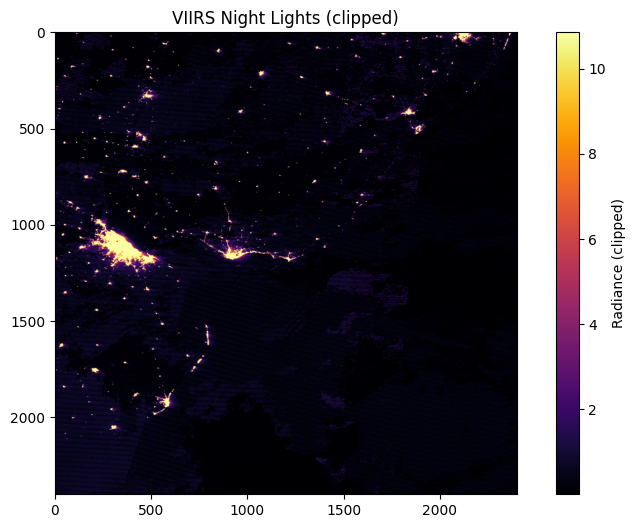

In [167]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

path = "VNP46A2.A2026104.h12v12.002.2026112102916.h5"

with h5py.File(path, "r") as f:
    # Ver estructura (opcional para debug)
    # print(list(f.keys()))

    data = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/Gap_Filled_DNB_BRDF-Corrected_NTL"][:]

img = np.array(data, dtype=float)

img[img <= 0] = np.nan

vmin, vmax = np.nanpercentile(img, [5, 99.2])

plt.figure(figsize=(10,6))
plt.imshow(img, cmap="inferno", vmin=vmin, vmax=vmax)
plt.colorbar(label="Radiance (clipped)")
plt.title("VIIRS Night Lights (clipped)")
plt.show()

In [53]:
!wget \
  --load-cookies ~/.urs_cookies \
  --save-cookies ~/.urs_cookies \
  --keep-session-cookies \
  --auth-no-challenge=on \
  --content-disposition \
  "https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VNP46A2/VNP46A2.A2025346.h12v12.002.2025356210757.h5"

--2026-04-22 13:14:25--  https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VNP46A2/VNP46A2.A2025346.h12v12.002.2025356210757.h5
Resolving data.laadsdaac.earthdatacloud.nasa.gov (data.laadsdaac.earthdatacloud.nasa.gov)... 18.155.1.112, 18.155.1.27, 18.155.1.59, ...
Connecting to data.laadsdaac.earthdatacloud.nasa.gov (data.laadsdaac.earthdatacloud.nasa.gov)|18.155.1.112|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://d13j1jds5ybppo.cloudfront.net/s3-8d80a21348b33e9c2ee6e0a8ac41d7b1/prod-lads.s3.us-west-2.amazonaws.com/VNP46A2/VNP46A2.A2025346.h12v12.002.2025356210757.h5?A-userid=lcaravaggio&Expires=1776867265&Signature=M6l2t~QQh~6zb5GdHopvxp9eMzUQ1EysuPjb-DpM5ZqNArQP59--J70y-VK0hWAWUyK2LPBRz9Va71dK~g3RayuUAdF6b-pL0~2ZFfa8zB4dxuHJlbgdCW~O~yXUJkfyahxlSR8YeiipkKuXFvH1dIsq4yUhHcTQdFrJFBtZQCRgJEsGnaQ1lt-54QNfTScq-pOIBqyo7N4zqoOAgAk3V~4LB3xXr2iUIrLmoBxomUessm-AcN9hN0UCbbn9KMdxm6s-p3oe1E-NEtaQ8yBmUgQB8~OsdbBYZehKZiDJ45I7xbGv-sg8jbQhXEEECJf1kFLH

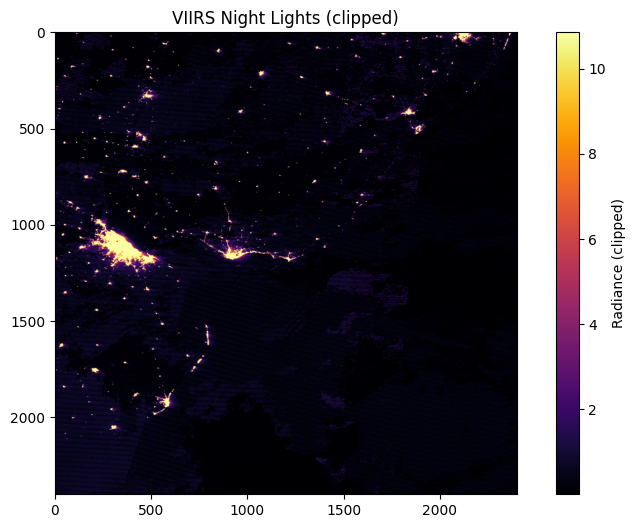

In [168]:
path = "/content/VNP46A2.A2026104.h12v12.002.2026112102916.h5"


with h5py.File(path, "r") as f:
    # Ver estructura (opcional para debug)
    # print(list(f.keys()))

    data = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/Gap_Filled_DNB_BRDF-Corrected_NTL"][:]

img = np.array(data, dtype=float)

img[img <= 0] = np.nan

vmin, vmax = np.nanpercentile(img, [5, 99.2])

plt.figure(figsize=(10,6))
plt.imshow(img, cmap="inferno", vmin=vmin, vmax=vmax)
plt.colorbar(label="Radiance (clipped)")
plt.title("VIIRS Night Lights (clipped)")
plt.show()

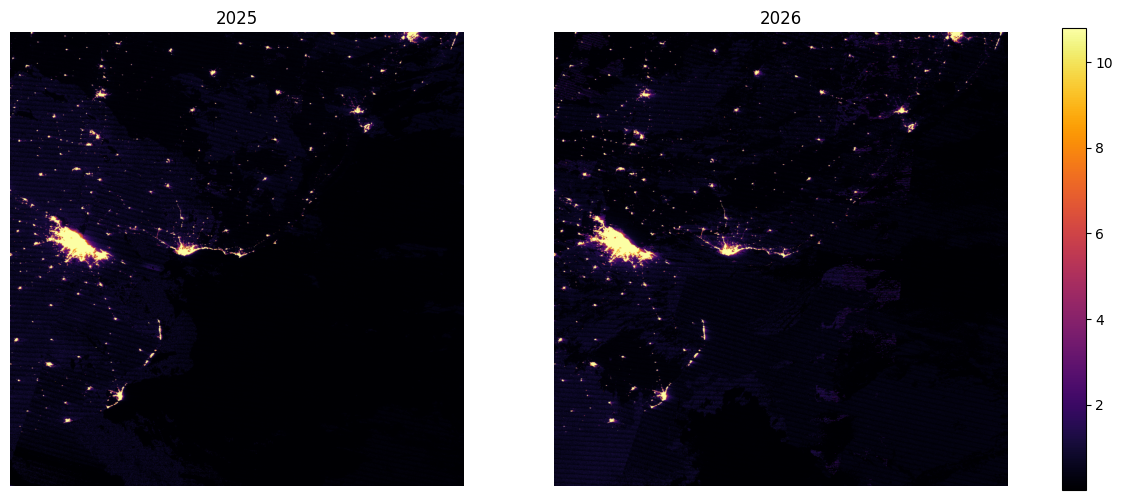

In [170]:
import h5py
import numpy as np

def load_viirs(path):
    with h5py.File(path, "r") as f:
        data = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/Gap_Filled_DNB_BRDF-Corrected_NTL"][:]

    img = data.astype(float)
    img[img <= 0] = np.nan
    return img

path_2025='/content/VNP46A2.A2025346.h12v12.002.2025356210757.h5'
path_2026='/content/VNP46A2.A2026104.h12v12.002.2026112102916.h5'

img_2025 = load_viirs(path_2025)
img_2026 = load_viirs(path_2026)

vmin = np.nanpercentile(np.stack([img_2025, img_2026]), 5)
vmax = np.nanpercentile(np.stack([img_2025, img_2026]), 99.2)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14,6))

ax[0].imshow(img_2025, cmap="inferno", vmin=vmin, vmax=vmax)
ax[0].set_title("2025")

ax[1].imshow(img_2026, cmap="inferno", vmin=vmin, vmax=vmax)
ax[1].set_title("2026")

for a in ax:
    a.axis("off")

plt.colorbar(ax[1].images[0], ax=ax, fraction=0.03)
plt.show()

In [171]:
gdp_proxy_2025 = np.nansum(img_2025)
gdp_proxy_2026 = np.nansum(img_2026)

growth = (gdp_proxy_2026 - gdp_proxy_2025) / gdp_proxy_2025
print("Crecimiento proxy:", growth)

Crecimiento proxy: 0.09825334098600122
